In [2]:
import kagglehub, os, os.path, pathlib
import os.path

# Set custom cache directories (as in your original notebook)
os.environ['KAGGLE_CACHE_DIR'] = r'E:\.cache\kagglehub' 
os.environ['XDG_CACHE_HOME'] = r'E:\.cache' 

# ⚠️ CHANGE 1: Use the BreaKHis dataset slug
path = kagglehub.dataset_download("kurshidbasheer/breakhisbreast-cancer-histopathological-images")
print("Dataset downloaded to:", path)

for root, dirs, files in os.walk(path):
    print(root)
    break  

E:\AI\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\aksha\.cache\kagglehub\datasets\kurshidbasheer\breakhisbreast-cancer-histopathological-images\versions\1
C:\Users\aksha\.cache\kagglehub\datasets\kurshidbasheer\breakhisbreast-cancer-histopathological-images\versions\1


In [3]:
# NOTE: For BreaKHis, the main folder is often at the root of the download
# or inside a single top-level folder. Adjust this based on the actual Kaggle download structure.
# Assuming the main data folder is at the root or within the first subdirectory based on typical Kaggle structure for this dataset.
data_dir = path # Start search at the root


In [4]:
import pathlib
data_dir = pathlib.Path(data_dir)
print("Data folder (starting point for search):", data_dir)


Data folder (starting point for search): C:\Users\aksha\.cache\kagglehub\datasets\kurshidbasheer\breakhisbreast-cancer-histopathological-images\versions\1


In [5]:
import os, pathlib

# This step is kept to help locate the actual Train/Test folders in the BreaKHis structure
for root, dirs, files in os.walk(data_dir):
    print("📂", root)
    for d in dirs:
        print("  └──", d)
    # Heuristic to find the 'raw' data folder if it's nested (common in Kaggle downloads)
    if 'BreaKHis' in root or len(dirs) > 2:
        data_dir = pathlib.Path(root)
    if len(dirs)>0: # only show subfolders of the relevant folder
        break 


📂 C:\Users\aksha\.cache\kagglehub\datasets\kurshidbasheer\breakhisbreast-cancer-histopathological-images\versions\1
  └── BreaKHis_v1


In [6]:
# This cell is mostly redundant, but kept for consistency, the heavy lifting is in cell 6
class_names = sorted([d.name for d in data_dir.iterdir() if d.is_dir()])
print("Detected top-level folders (may not be classes):", class_names)


Detected top-level folders (may not be classes): ['BreaKHis_v1']


In [7]:
import os, pathlib, random
from collections import defaultdict
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf

base_path = data_dir # Use the potentially adjusted data_dir from cell 4

print("Top-level directory:", base_path)

trainval_folder = None
test_folder = None

# For BreaKHis, we must perform a global recursive scan and manual split (no predefined Train/Val/Test folders in the download)
print("\nBreaKHis dataset has no standard Train/Val/Test folders. Performing global recursive scan and manual split...")

exts = ("*.png", "*.jpg","*.jpeg","*.tif","*.tiff")
global_files = []
for ext in exts:
    global_files += list(base_path.rglob(ext))

if len(global_files) == 0:
    raise RuntimeError("No image files found anywhere under dataset folder.")

# Infer labels from the parent folder names (e.g., 'benign' or 'malignant')
gp = [str(p) for p in global_files]

def infer_label_from_path(p):
    # Look for 'benign' or 'malignant' anywhere in the path, ignoring case.
    # This is a robust heuristic for BreaKHis structure.
    path_parts = pathlib.Path(p).parts
    if any('malignant' in part.lower() for part in path_parts):
        return 'malignant'
    elif any('benign' in part.lower() for part in path_parts):
        return 'benign'
    return 'unknown'

inferred_labels = [infer_label_from_path(p) for p in gp]
valid_files = [p for p, l in zip(gp, inferred_labels) if l in ('benign', 'malignant')]
valid_labels = [l for l in inferred_labels if l in ('benign', 'malignant')]

if len(valid_files) < len(global_files):
    print(f"Warning: Ignored {len(global_files) - len(valid_files)} non-class-labeled files (or in unknown structure).")

# The classes are explicitly defined as 2 for binary task
all_classes = ['benign', 'malignant']
paths = valid_files
labels = [all_classes.index(l) for l in valid_labels]

# Split the data: Train (70%), Val (10%), Test (20%)
# First split: Training/Validation (80%) vs. Test (20%)
paths_tmp, test_paths, labels_tmp, test_labels = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=42)

# Second split: Training (7/8 of remaining, ~70% of total) vs. Validation (1/8 of remaining, ~10% of total)
train_paths, val_paths, train_labels, val_labels = train_test_split(paths_tmp, labels_tmp, test_size=0.125, stratify=labels_tmp, random_state=42)

from collections import Counter
print("\nFinal dataset splits (BreaKHis):")
print(" Total images found:", len(paths))
print(" Train:", len(train_paths))
print(" Val  :", len(val_paths))
print(" Test :", len(test_paths))

def counts_per_class(paths, labels, cls_list):
    cnt = Counter()
    for p,l in zip(paths,labels):
        cnt[cls_list[l]] += 1
    return cnt

print("\nTrain class counts:", counts_per_class(train_paths, train_labels, all_classes))
print("Val   class counts:", counts_per_class(val_paths, val_labels, all_classes))
print("Test  class counts:", counts_per_class(test_paths, test_labels, all_classes))

IMG_SIZE = 256
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_fn(path, label, augment=False):
    img = tf.io.read_file(path)
    # BreaKHis images are PNG, original code used JPEG. Using decode_image is safer.
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    if augment:
        # simple augmentations
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.08)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, label

def make_ds(paths, labels, batch, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(10000, len(paths)))
    ds = ds.map(lambda p,l: preprocess_fn(p,l,augment=augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch).prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_labels, BATCH_SIZE, shuffle=True, augment=True)
val_ds   = make_ds(val_paths, val_labels, BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_ds(test_paths, test_labels, BATCH_SIZE, shuffle=False, augment=False)

print("\nTF datasets ready. Examples from one batch:")
for images, labels in train_ds.take(1):
    print(" batch images shape:", images.shape)
    print(" batch labels shape:", labels.shape)
    break

import pickle
with open("breakhis_splits.pkl","wb") as f:
    pickle.dump({
        "classes": all_classes,
        "train_paths": train_paths,
        "train_labels": train_labels,
        "val_paths": val_paths,
        "val_labels": val_labels,
        "test_paths": test_paths,
        "test_labels": test_labels
    }, f)

print("\nSaved split metadata to breakhis_splits.pkl")


Top-level directory: C:\Users\aksha\.cache\kagglehub\datasets\kurshidbasheer\breakhisbreast-cancer-histopathological-images\versions\1

BreaKHis dataset has no standard Train/Val/Test folders. Performing global recursive scan and manual split...

Final dataset splits (BreaKHis):
 Total images found: 7909
 Train: 5536
 Val  : 791
 Test : 1582

Train class counts: Counter({'malignant': 3800, 'benign': 1736})
Val   class counts: Counter({'malignant': 543, 'benign': 248})
Test  class counts: Counter({'malignant': 1086, 'benign': 496})

TF datasets ready. Examples from one batch:
 batch images shape: (16, 256, 256, 3)
 batch labels shape: (16,)

Saved split metadata to breakhis_splits.pkl


In [8]:
import tensorflow as tf
try:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled (non-fatal):", e)


Your GPUs may run slowly with dtype policy mixed_float16 because they do not have compute capability of at least 7.0. Your GPUs:
  DML, no compute capability (probably not an Nvidia GPU) (x2)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
Mixed precision enabled: <Policy "mixed_float16">


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import pickle, numpy as np, os

# Load the new split file
splits = pickle.load(open("breakhis_splits.pkl","rb"))

# ⚠️ CHANGE 2: Set NUM_CLASSES to 2 for BreaKHis binary classification
NUM_CLASSES = 2 
IMG_SIZE = 256

# --- Start of StatisticalWaveAttention Layer (copied from original) ---
class StatisticalWaveAttention(layers.Layer):
    def __init__(self, mode='pearson', a=3.1, h=1.065, c_param=1.1, k=0.1, **kwargs):
        super().__init__(**kwargs)
        assert mode in ('pearson', 'spearman')
        self.mode = mode
        self.a = a
        self.h = h
        self.c_param = c_param
        self.k = k
        self.conv1d = None
        self.bn = None
        self.sig = None

    def build(self, input_shape):
        self.H = input_shape[1]
        self.W = input_shape[2]
        self.C = int(input_shape[3])
        # Enforce dtypes for stability with mixed precision
        self.conv1d = layers.Conv1D(filters=self.C, kernel_size=3, padding='same', activation='relu', dtype=self.compute_dtype)
        self.bn = layers.BatchNormalization(dtype=self.compute_dtype)
        self.sig = layers.Activation('sigmoid', dtype=self.compute_dtype)
        super().build(input_shape)

    def rank_transform(self, x):
        order = tf.argsort(x, axis=1)
        ranks = tf.argsort(order, axis=1)
        ranks = tf.cast(ranks, tf.float32) 
        denom = tf.cast(tf.shape(x)[1] - 1, tf.float32)
        denom = tf.where(denom <= 0.0, 1.0, denom)
        ranks = ranks / denom
        return tf.cast(ranks, x.dtype)

    def compute_pcc_cos(self, x):
        orig_dtype = x.dtype
        x32 = tf.cast(x, tf.float32)
        B = tf.shape(x32)[0]; H = tf.shape(x32)[1]; W = tf.shape(x32)[2]; C = tf.shape(x32)[3]
        HW = H * W
        x_flat = tf.reshape(x32, [B, HW, C])  
        mu = tf.reduce_mean(x_flat, axis=2)
        mu_mean = tf.reduce_mean(mu, axis=1, keepdims=True) 
        mu_c = mu - mu_mean

        x_mean = tf.reduce_mean(x_flat, axis=1, keepdims=True)
        x_c = x_flat - x_mean

        num = tf.reduce_sum(tf.expand_dims(mu_c, -1) * x_c, axis=1)
        mu_sq = tf.reduce_sum(tf.square(mu_c), axis=1, keepdims=True)
        x_sq = tf.reduce_sum(tf.square(x_c), axis=1)
        denom = tf.sqrt(tf.maximum(mu_sq * x_sq, 1e-12))
        pcc = num / (denom + 1e-12)

        mu_norm = tf.norm(mu, axis=1, keepdims=True)
        x_norms = tf.norm(x_flat, axis=1)
        cos = tf.reduce_sum(tf.expand_dims(mu, -1) * x_flat, axis=1) / ((mu_norm * x_norms) + 1e-12)

        pcc = tf.clip_by_value(pcc, -1.0, 1.0)
        cos = tf.clip_by_value(cos, -1.0, 1.0)

        return tf.cast(pcc, orig_dtype), tf.cast(cos, orig_dtype)

    def call(self, inputs, training=None):
        in_dtype = inputs.dtype
        B = tf.shape(inputs)[0]; H = tf.shape(inputs)[1]; W = tf.shape(inputs)[2]; C = tf.shape(inputs)[3]
        HW = H * W

        if self.mode == 'pearson':
            pcc, cos = self.compute_pcc_cos(inputs)
            fss = 0.5 * (pcc + cos)  # dtype = in_dtype
        else:
            x_flat = tf.reshape(tf.cast(inputs, tf.float32), [B, HW, C])
            mu = tf.reduce_mean(x_flat, axis=2)  # [B,HW]
            mu_ranks = self.rank_transform(tf.cast(mu, in_dtype))
            x_trans = tf.transpose(tf.cast(x_flat, in_dtype), perm=[0,2,1])  # [B,C,HW]
            x_rows = tf.reshape(x_trans, [-1, HW])  # [B*C, HW]
            x_ranks_rows = self.rank_transform(x_rows)
            x_ranks = tf.reshape(x_ranks_rows, [B, C, HW])
            x_ranks = tf.transpose(x_ranks, perm=[0,2,1])  # [B,HW,C]

            mu32 = tf.cast(mu_ranks, tf.float32)
            x32 = tf.cast(x_ranks, tf.float32)
            mu_mean = tf.reduce_mean(mu32, axis=1, keepdims=True)
            mu_c = mu32 - mu_mean
            x_mean = tf.reduce_mean(x32, axis=1, keepdims=True)
            x_c = x32 - x_mean
            num = tf.reduce_sum(tf.expand_dims(mu_c, -1) * x_c, axis=1)
            mu_sq = tf.reduce_sum(tf.square(mu_c), axis=1, keepdims=True)
            x_sq = tf.reduce_sum(tf.square(x_c), axis=1)
            denom = tf.sqrt(tf.maximum(mu_sq * x_sq, 1e-12))
            pcc_ranks = num / (denom + 1e-12)
            mu_norm = tf.norm(mu32, axis=1, keepdims=True)
            x_norms = tf.norm(x32, axis=1)
            cos_ranks = tf.reduce_sum(tf.expand_dims(mu32, -1) * x32, axis=1) / ((mu_norm * x_norms) + 1e-12)
            pcc = tf.cast(pcc_ranks, in_dtype)
            cos = tf.cast(cos_ranks, in_dtype)
            fss = 0.5 * (pcc + cos)

        fss32 = tf.cast(fss, tf.float32)
        scores32 = tf.exp(self.a * (fss32 - self.h)) * self.c_param + self.k 
        scores = tf.clip_by_value(scores32, 0.0, 1.0)
        scores = tf.cast(scores, in_dtype)  
        weights = tf.reshape(scores, [-1, 1, 1, tf.shape(scores)[1]]) 

        x_weighted = inputs * weights

        seq = tf.reshape(x_weighted, [-1, HW, inputs.shape[-1]]) 
        conv_out = self.conv1d(seq)
        conv_out = self.bn(conv_out, training=training)
        conv_out = self.sig(conv_out)
        conv_out = tf.reshape(conv_out, [-1, H, W, inputs.shape[-1]])
        out = inputs * conv_out
        return out

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"mode": self.mode, "a": self.a, "h": self.h, "c_param": self.c_param, "k": self.k})
        return cfg

# --- End of StatisticalWaveAttention Layer ---

def build_sawl_net(img_size=IMG_SIZE, num_classes=NUM_CLASSES, use_pcc=True, use_srcc=True):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    base = tf.keras.applications.MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')

    outer_name = 'block_1_expand_relu'
    inner_name = 'block_13_expand_relu'
    outer_feat = base.get_layer(outer_name).output
    inner_feat = base.get_layer(inner_name).output
    trunk = base.output

    outer_up = None
    inner_up = None
    if use_pcc:
        outer_att = StatisticalWaveAttention(mode='pearson', name='pcc_att')(outer_feat)
        outer_up = layers.Conv2D(trunk.shape[-1], kernel_size=1, padding='same', activation='relu')(outer_att)
        outer_up = layers.Resizing(trunk.shape[1], trunk.shape[2], interpolation='bilinear')(outer_up)

    if use_srcc:
        inner_att = StatisticalWaveAttention(mode='spearman', name='srcc_att')(inner_feat)
        inner_up = layers.Conv2D(trunk.shape[-1], kernel_size=1, padding='same', activation='relu')(inner_att)
        inner_up = layers.Resizing(trunk.shape[1], trunk.shape[2], interpolation='bilinear')(inner_up)

    merged = [trunk]
    if outer_up is not None:
        merged.append(outer_up)
    if inner_up is not None:
        merged.append(inner_up)

    if len(merged) > 1:
        x = layers.Concatenate()(merged)
        x = layers.Conv2D(512, kernel_size=3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    else:
        x = trunk

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    # Note: Use 'float32' output dtype for softmax for stable loss calculation
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x) 

    model = Model(inputs, outputs, name=f"SAWLNet_pcc_{use_pcc}_srcc_{use_srcc}")
    return model


build_sawl_net_fixed = build_sawl_net # Alias the main build function for consistency
model_fixed = build_sawl_net_fixed()
model_fixed.summary()

for imgs, labs in train_ds.take(1):
    imgs_small = imgs  
    _ = model_fixed(imgs_small, training=False)
    print("Forward pass OK, output shape:", _.shape)
    break

build_sawl_net = build_sawl_net_fixed
model = model_fixed
print("Rebuilt SAWL-Net with dtype-safe attention layer.")

Model: "SAWLNet_pcc_True_srcc_True"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 128, 128, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 128, 128, 32  128         ['Conv1[0][0]']                  
                                )                                        

In [ ]:
import os, tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping, CSVLogger

print("Clearing session and forcing float32 policy...")
K.clear_session()
try:
    # Force float32 policy for final training stability, overriding mixed_float16 if needed
    tf.keras.mixed_precision.set_global_policy('float32')
except Exception as e:
    print("Could not set mixed precision policy (non-fatal):", e)
print("Current policy:", tf.keras.mixed_precision.global_policy())

try:
    model = build_sawl_net(img_size=IMG_SIZE, num_classes=NUM_CLASSES, use_pcc=True, use_srcc=True)
except Exception as e:
    print("Error building model:", e)
    raise

LR = 1e-5
opt = tf.keras.optimizers.Adam(learning_rate=LR)
# Note: The loss is sparse_categorical_crossentropy because labels are integer encoded (0 or 1)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

os.makedirs("models", exist_ok=True)
checkpoint_path = "models/sawl_breakhis_best_full.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, verbose=1, min_lr=1e-7),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    CSVLogger("models/sawl_breakhis_training_log.csv")
]

if os.path.exists(checkpoint_path):
    try:
        print("Found existing checkpoint. Loading weights and continuing training from that checkpoint...")
        model.load_weights(checkpoint_path)
        print("Weights loaded from", checkpoint_path)
    except Exception as e:
        print("Could not load checkpoint weights directly (will continue training from scratch). Error:", e)

EPOCHS = 10

print("Starting training for", EPOCHS, "epochs (this may take a while).")
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=EPOCHS,
                    callbacks=callbacks)

model.save("models/sawl_breakhis_saved_model_float32", include_optimizer=True)
print("Training done. Best checkpoint saved to:", checkpoint_path)
print("SavedModel exported to: models/sawl_breakhis_saved_model_float32")

Clearing session and forcing float32 policy...
Current policy: <Policy "float32">
Model: "SAWLNet_pcc_True_srcc_True"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 128, 128, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 128, 128, 32  128         ['Conv1[0][0]']          

✅ Loaded model from models/sawl_breakhis_best_full.h5

=================== 🧩 SAWL-BreakHis Detailed Evaluation ===================
✅ Accuracy:            0.9728
✅ Precision (weighted): 0.9734   | Macro: 0.9643
✅ Recall    (weighted): 0.9728   | Macro: 0.9736
✅ F1-Score  (weighted): 0.9730   | Macro: 0.9687

📘 Classification Report:
              precision    recall  f1-score   support

      benign     0.9398    0.9758    0.9575       496
   malignant     0.9888    0.9715    0.9800      1086

    accuracy                         0.9728      1582
   macro avg     0.9643    0.9736    0.9687      1582
weighted avg     0.9734    0.9728    0.9730      1582



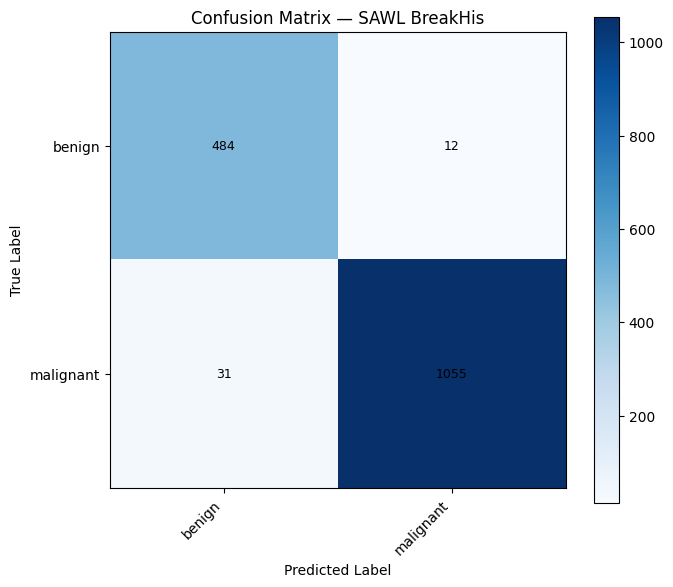

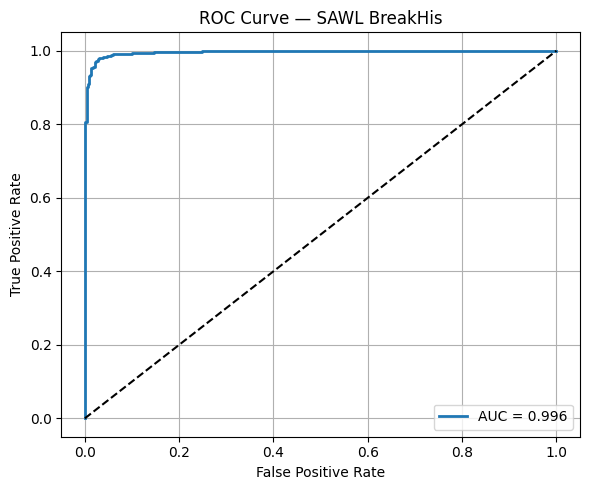

ROC–AUC (binary): 0.9958


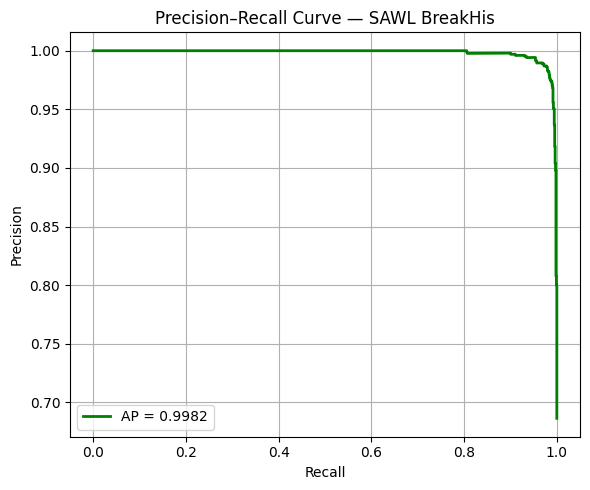

Average Precision (AP): 0.9982

📁 All figures saved in 'results/figs_breakhis/' and summary in 'results/metrics_breakhis_summary.txt'.


In [10]:
# ============================================================
# 🧩 SAWL BreakHis — Full Evaluation Metrics & Visualizations
# ============================================================

import os, pickle, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

# ------------------------------------------------------------
# 🔹 Load Model
# ------------------------------------------------------------
custom_objects = {"StatisticalWaveAttention": StatisticalWaveAttention}
best_path = "models/sawl_breakhis_best_full.h5"

if os.path.exists(best_path):
    try:
        best_model = tf.keras.models.load_model(best_path, custom_objects=custom_objects, compile=False)
        print(f"✅ Loaded model from {best_path}")
    except Exception as e:
        print("⚠️ Error loading .h5; trying SavedModel:", e)
        best_model = tf.keras.models.load_model("models/sawl_breakhis_saved_model_float32",
                                                custom_objects=custom_objects, compile=False)
        print("✅ Loaded SavedModel folder.")
else:
    print("⚠️ No checkpoint found — using in-memory model variable.")
    try:
        best_model
    except NameError:
        raise RuntimeError("No model in memory; train or load checkpoint first.")
    best_model = model

# Optional recompile (not needed for inference, but harmless)
best_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ------------------------------------------------------------
# 🔹 Evaluate on Test Set
# ------------------------------------------------------------
y_true, y_pred, y_prob = [], [], []
for imgs, labs in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_prob.append(preds)
    y_pred.append(np.argmax(preds, axis=1))
    y_true.append(labs.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_prob = np.concatenate(y_prob)

# ------------------------------------------------------------
# 🔹 Class Names
# ------------------------------------------------------------
splits = pickle.load(open("breakhis_splits.pkl", "rb"))
class_names = splits["classes"]

# ------------------------------------------------------------
# 📊 1. Core Metrics
# ------------------------------------------------------------
acc = accuracy_score(y_true, y_pred)
prec_w = precision_score(y_true, y_pred, average='weighted')
rec_w = recall_score(y_true, y_pred, average='weighted')
f1_w = f1_score(y_true, y_pred, average='weighted')
prec_m = precision_score(y_true, y_pred, average='macro')
rec_m = recall_score(y_true, y_pred, average='macro')
f1_m = f1_score(y_true, y_pred, average='macro')

print("\n=================== 🧩 SAWL-BreakHis Detailed Evaluation ===================")
print(f"✅ Accuracy:            {acc:.4f}")
print(f"✅ Precision (weighted): {prec_w:.4f}   | Macro: {prec_m:.4f}")
print(f"✅ Recall    (weighted): {rec_w:.4f}   | Macro: {rec_m:.4f}")
print(f"✅ F1-Score  (weighted): {f1_w:.4f}   | Macro: {f1_m:.4f}")
print("==========================================================================\n")

print("📘 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ------------------------------------------------------------
# 🔢 2. Confusion Matrix Visualization
# ------------------------------------------------------------
import matplotlib.pyplot as plt
os.makedirs("results/figs_breakhis", exist_ok=True)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix — SAWL BreakHis")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
for i in range(len(cm)):
    for j in range(len(cm[i])):
        plt.text(j, i, str(cm[i][j]), ha='center', va='center', color='black', fontsize=9)
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha='right')
plt.yticks(np.arange(len(class_names)), class_names)
plt.tight_layout()
plt.savefig("results/figs_breakhis/confusion_matrix.png", dpi=300)
plt.show()

# ------------------------------------------------------------
# 📈 3. ROC–AUC Curves
# ------------------------------------------------------------
try:
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    if y_prob.shape[1] == 2:
        # Binary case
        fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title("ROC Curve — SAWL BreakHis")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("results/figs_breakhis/roc_auc.png", dpi=300)
        plt.show()
        print(f"ROC–AUC (binary): {roc_auc:.4f}")

    else:
        # Multiclass case
        fpr, tpr, roc_auc = {}, {}, {}
        for i, cls in enumerate(class_names):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(class_names)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(class_names)
        roc_auc_macro = auc(all_fpr, mean_tpr)

        plt.figure(figsize=(8, 7))
        for i, cls in enumerate(class_names):
            plt.plot(fpr[i], tpr[i], lw=2, label=f"{cls} (AUC={roc_auc[i]:.3f})")
        plt.plot(all_fpr, mean_tpr, color='black', lw=3, linestyle='--',
                 label=f"Macro Avg (AUC={roc_auc_macro:.3f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title("Multiclass ROC–AUC — SAWL BreakHis")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(fontsize=9)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("results/figs_breakhis/roc_auc_multiclass.png", dpi=300)
        plt.show()

        print("\nPer-Class AUC Values:")
        for cls, auc_val in roc_auc.items():
            print(f"  {class_names[cls]:25s}: {auc_val:.4f}")
        print(f"Macro-average ROC–AUC: {roc_auc_macro:.4f}")

except Exception as e:
    print("ROC–AUC generation failed:", e)

# ------------------------------------------------------------
# 📉 4. Precision–Recall Curve
# ------------------------------------------------------------
try:
    if y_prob.shape[1] == 2:
        precision, recall, _ = precision_recall_curve(y_true, y_prob[:, 1])
        ap = average_precision_score(y_true, y_prob[:, 1])
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, color='green', lw=2, label=f"AP = {ap:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve — SAWL BreakHis")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("results/figs_breakhis/precision_recall.png", dpi=300)
        plt.show()
        print(f"Average Precision (AP): {ap:.4f}")
    else:
        precision, recall, _ = precision_recall_curve(y_true_bin.ravel(), y_prob.ravel())
        ap = average_precision_score(y_true_bin, y_prob, average='micro')
        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, color='green', lw=2, label=f"Micro-Avg AP = {ap:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision–Recall Curve — SAWL BreakHis")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig("results/figs_breakhis/precision_recall_multiclass.png", dpi=300)
        plt.show()
        print(f"Average Precision (micro): {ap:.4f}")
except Exception as e:
    print("Precision–Recall generation failed:", e)

# ------------------------------------------------------------
# 💾 5. Save Metrics Summary
# ------------------------------------------------------------
os.makedirs("results", exist_ok=True)
with open("results/metrics_breakhis_summary.txt", "w") as f:
    f.write(f"Accuracy:  {acc:.4f}\n")
    f.write(f"Precision (weighted/macro): {prec_w:.4f} / {prec_m:.4f}\n")
    f.write(f"Recall    (weighted/macro): {rec_w:.4f} / {rec_m:.4f}\n")
    f.write(f"F1-Score  (weighted/macro): {f1_w:.4f} / {f1_m:.4f}\n")
    if y_prob.shape[1] == 2:
        f.write(f"ROC–AUC (binary): {roc_auc:.4f}\n")
        f.write(f"Average Precision: {ap:.4f}\n")
    else:
        f.write(f"ROC–AUC (macro): {roc_auc_macro:.4f}\n")
        f.write(f"Average Precision (micro): {ap:.4f}\n")

print("\n📁 All figures saved in 'results/figs_breakhis/' and summary in 'results/metrics_breakhis_summary.txt'.")


In [12]:
# ---------------------------
# Cell: Improved selective MC Δ-addition (majority + stable + improvement)
# ---------------------------
import os, gc, numpy as np, tensorflow as tf, pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

OUTDIR = "results/figs_breakhis"
os.makedirs(OUTDIR, exist_ok=True)

# safety checks
for v in ["best_model", "test_ds", "y_true", "y_pred", "y_prob", "class_names"]:
    if v not in globals():
        raise RuntimeError(f"Required variable '{v}' not found. Run your base eval cell first.")

MC_SAMPLES = 8          # MC passes for candidate only
NOISE_STD = 0.005       # small jitter
MAJORITY_FRAC = 0.7     # require >=70% of MC votes same class
DELTA_THRESH = 0.003    # low variance requirement
MIN_IMPROVE = 0.02      # MC top-prob must exceed base top by this to accept
CONF_SKIP = 0.95        # skip MC if base top-prob >= this

def enable_dropout(m):
    for layer in m.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            layer.training = True

y_pred_refined = y_pred.copy()
changed = []
idx_ptr = 0
candidates = 0
accepted = 0

for imgs, _ in tqdm(test_ds, desc="Improved MC Δ-Addition"):
    imgs = tf.cast(imgs, tf.float32)
    b = imgs.shape[0]
    base_probs_batch = y_prob[idx_ptr: idx_ptr + b]
    top1 = np.max(base_probs_batch, axis=1)
    # compute top2 safely
    if base_probs_batch.shape[1] > 1:
        top2 = np.partition(base_probs_batch, -2, axis=1)[:, -2]
    else:
        top2 = np.zeros_like(top1)

    for j in range(b):
        base_top = float(top1[j])
        if base_top >= CONF_SKIP:
            continue  # skip very confident samples
        candidates += 1
        img = imgs[j:j+1]
        votes = []
        probs_accum = None
        for s in range(MC_SAMPLES):
            noisy = img + tf.random.normal(tf.shape(img), stddev=NOISE_STD)
            enable_dropout(best_model)
            p = best_model(noisy, training=True).numpy().reshape(-1)
            votes.append(int(np.argmax(p)))
            if probs_accum is None:
                probs_accum = p.astype(np.float64)
            else:
                probs_accum += p
        mean_probs = probs_accum / MC_SAMPLES
        mc_top = float(np.max(mean_probs))
        mc_pred = int(np.argmax(mean_probs))
        # vote majority fraction
        votes = np.array(votes)
        counts = np.bincount(votes, minlength=mean_probs.size)
        maj_frac = counts[mc_pred] / MC_SAMPLES
        # variance-based delta
        # compute variance across MC for the predicted class probability
        # (we recompute quickly)
        class_probs = []
        for s in range(MC_SAMPLES):
            noisy = img + tf.random.normal(tf.shape(img), stddev=NOISE_STD)
            enable_dropout(best_model)
            p = best_model(noisy, training=True).numpy().reshape(-1)
            class_probs.append(p[mc_pred])
        var_mc = float(np.var(class_probs))
        # acceptance criteria
        if (maj_frac >= MAJORITY_FRAC and var_mc < DELTA_THRESH and (mc_top >= base_top + MIN_IMPROVE)):
            global_idx = idx_ptr + j
            base_pred = int(np.argmax(base_probs_batch[j]))
            if mc_pred != base_pred:
                y_pred_refined[global_idx] = mc_pred
                changed.append({
                    "index": int(global_idx),
                    "true": int(y_true[global_idx]),
                    "base_pred": base_pred,
                    "mc_pred": mc_pred,
                    "base_top": base_top,
                    "mc_top": mc_top,
                    "maj_frac": maj_frac,
                    "var_mc": var_mc
                })
                accepted += 1
    idx_ptr += b
    gc.collect()

acc_before = accuracy_score(y_true, y_pred)
acc_after = accuracy_score(y_true, y_pred_refined)
print("Before:", acc_before, "After:", acc_after, "Accepted:", accepted, "Candidates:", candidates)

# save outcomes
np.savez(os.path.join(OUTDIR, "mc_delta_improved_results.npz"),
         y_true=y_true, y_pred_base=y_pred, y_pred_refined=y_pred_refined)
if changed:
    pd.DataFrame(changed).to_csv(os.path.join(OUTDIR, "mc_delta_improved_changed.csv"), index=False)
    display(pd.DataFrame(changed).head(12))
print("Saved:", OUTDIR)


Improved MC Δ-Addition: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [07:43<00:00,  4.68s/it]

Before: 0.972819216182048 After: 0.9734513274336283 Accepted: 31 Candidates: 212


,index,true,base_pred,mc_pred,base_top,mc_top,maj_frac,var_mc
0,13,0,0,1,0.730431,0.808753,1.0,0.000014
1,30,1,0,1,0.640785,0.812438,1.0,0.000072
2,89,1,0,1,0.592631,0.803665,1.0,0.000038
3,127,1,0,1,0.565473,0.807874,1.0,0.000037
4,231,0,0,1,0.633842,0.808124,1.0,0.000023
5,341,0,0,1,0.745387,0.811145,1.0,0.000015
6,414,1,0,1,0.640115,0.808255,1.0,0.000040
7,444,0,0,1,0.593164,0.810173,1.0,0.000048
8,523,1,0,1,0.562163,0.805635,1.0,0.000032
9,692,1,0,1,0.535303,0.810036,1.0,0.000017


Saved: results/figs_breakhis


In [13]:
# ---------------------------
# Cell: TTA-based Δ-addition (augmentations ensemble)
# ---------------------------
import os, numpy as np, tensorflow as tf, pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score

OUTDIR = "results/figs_breakhis"
os.makedirs(OUTDIR, exist_ok=True)

# augmentations (you can add more)
def tta_augmentations(x):
    # x: (1, H, W, C)
    a = []
    a.append(x)                            # original
    a.append(tf.image.flip_left_right(x))  # flip
    a.append(tf.image.flip_up_down(x))     # up-down
    a.append(tf.image.rot90(x, k=1))      # rot 90
    a.append(tf.image.rot90(x, k=3))      # rot -90
    return a

y_pred_tta = y_pred.copy()
changed = []
idx_ptr = 0
TTA_MIN_IMPROVE = 0.02  # require improvement in top-prob vs base

for imgs, _ in tqdm(test_ds, desc="TTA refinement"):
    imgs = tf.cast(imgs, tf.float32)
    b = imgs.shape[0]
    base_probs_batch = y_prob[idx_ptr: idx_ptr + b]
    for j in range(b):
        img = imgs[j:j+1]
        tta_list = tta_augmentations(img)
        agg = None
        for aug in tta_list:
            p = best_model(aug, training=False).numpy().reshape(-1)
            if agg is None:
                agg = p
            else:
                agg += p
        mean_p = agg / len(tta_list)
        mc_top = float(np.max(mean_p))
        base_top = float(np.max(base_probs_batch[j]))
        base_pred = int(np.argmax(base_probs_batch[j]))
        mc_pred = int(np.argmax(mean_p))
        if mc_pred != base_pred and (mc_top >= base_top + TTA_MIN_IMPROVE):
            global_idx = idx_ptr + j
            y_pred_tta[global_idx] = mc_pred
            changed.append({"index": int(global_idx), "true": int(y_true[global_idx]),
                            "base_pred": base_pred, "tta_pred": mc_pred,
                            "base_top": base_top, "tta_top": mc_top})
    idx_ptr += b

acc_tta = accuracy_score(y_true, y_pred_tta)
print("Base acc:", accuracy_score(y_true, y_pred), "TTA acc:", acc_tta)
if changed:
    pd.DataFrame(changed).to_csv(os.path.join(OUTDIR,"tta_changed.csv"), index=False)
    display(pd.DataFrame(changed).head(12))


TTA refinement: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 99/99 [14:50<00:00,  9.00s/it]

Base acc: 0.972819216182048 TTA acc: 0.9462705436156763


,index,true,base_pred,tta_pred,base_top,tta_top
0,83,1,1,0,0.823297,0.996643
1,86,1,1,0,0.889735,0.989574
2,89,1,0,1,0.592631,0.715183
3,123,1,1,0,0.631337,0.722800
4,135,1,1,0,0.942111,0.993968
5,139,0,1,0,0.656197,0.718050
6,161,1,0,1,0.836424,0.978055
7,185,1,1,0,0.972867,1.000000
8,197,1,1,0,0.763643,0.927323
9,216,1,1,0,0.839102,0.994384


Using val_ds for calibration.
Calibration samples: 791


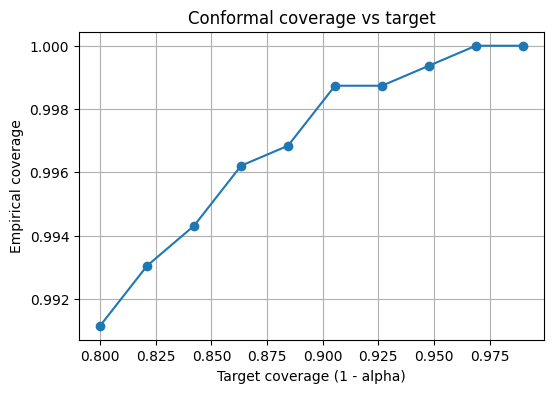

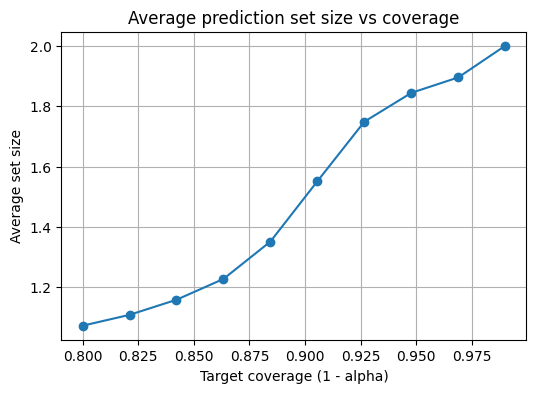

Example: for alpha=0.1 (target 0.9 coverage) -> quantile q: 0.99797106
Saved conformal plots to results/figs_breakhis/.
Saved prediction sets for alpha=0.1.


In [14]:
# -----------------------------
# Cell B: Split-Conformal Prediction (post-hoc, uses probabilities)
# -----------------------------
import os, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
os.makedirs("results/figs_breakhis", exist_ok=True)

# Choose calibration dataset (val_ds preferred)
if "val_ds" in globals():
    calib_ds = val_ds
    print("Using val_ds for calibration.")
else:
    print("⚠️ val_ds not found — using a subset of test_ds for conformal calibration (not ideal).")
    total_batches = 0
    for _ in test_ds:
        total_batches += 1
    take_b = max(1, int(0.1 * total_batches))
    calib_ds = test_ds.take(take_b)

# collect calibration probs & labels
calib_probs = []
calib_labels = []
for imgs, labs in calib_ds:
    p = best_model.predict(imgs, verbose=0)
    calib_probs.append(p)
    calib_labels.append(labs.numpy())
calib_probs = np.concatenate(calib_probs); calib_labels = np.concatenate(calib_labels)
print("Calibration samples:", calib_probs.shape[0])

# nonconformity score: s = 1 - p_true (lower is better)
idx = np.arange(len(calib_probs))
p_true = calib_probs[idx, calib_labels]
scores = 1.0 - np.clip(p_true, 1e-12, 1.0)

def conformal_quantile(alpha):
    # use (1 - alpha) quantile with +1 correction
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha))) - 1
    k = np.clip(k, 0, n - 1)
    q = np.sort(scores)[k]
    return q

# Evaluate coverage and avg set size for several alphas on the test set
alphas = np.linspace(0.01, 0.20, 10)
coverages = []
avg_sizes = []

# Gather test probs & labels (use previously computed y_prob & y_true)
probs_test = y_prob
labels_test = y_true

for alpha in alphas:
    q = conformal_quantile(alpha)
    # construct sets: include class c if 1 - p_c <= q  <=> p_c >= 1 - q
    threshold = 1.0 - q
    sets = (probs_test >= threshold).astype(int)
    set_sizes = sets.sum(axis=1)
    # coverage: true label included?
    included = (sets[np.arange(len(labels_test)), labels_test] == 1)
    coverage = included.mean()
    coverages.append(coverage)
    avg_sizes.append(set_sizes.mean())

plt.figure(figsize=(6,4))
plt.plot(1 - alphas, coverages, marker='o')
plt.xlabel("Target coverage (1 - alpha)")
plt.ylabel("Empirical coverage")
plt.title("Conformal coverage vs target")
plt.grid(True)
plt.savefig("results/figs_breakhis/conformal_coverage.png", dpi=300)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(1 - alphas, avg_sizes, marker='o')
plt.xlabel("Target coverage (1 - alpha)")
plt.ylabel("Average set size")
plt.title("Average prediction set size vs coverage")
plt.grid(True)
plt.savefig("results/figs_breakhis/conformal_setsize.png", dpi=300)
plt.show()

print("Example: for alpha=0.1 (target 0.9 coverage) -> quantile q:", conformal_quantile(0.1))
print("Saved conformal plots to results/figs_breakhis/.")

# Save a chosen target alpha (e.g., alpha=0.1) and produce final sets for test
target_alpha = 0.1
q_target = conformal_quantile(target_alpha)
threshold_target = 1.0 - q_target
sets_target = (probs_test >= threshold_target).astype(int)
np.savez("results/figs_breakhis/conformal_sets_alpha_0.1.npz",
         sets=sets_target, threshold=threshold_target, q=q_target)
print("Saved prediction sets for alpha=0.1.")


Using train_ds for reference features.
Using feature layer: dense
Collected reference features: (5536, 2)
Test features: (1582, 2)


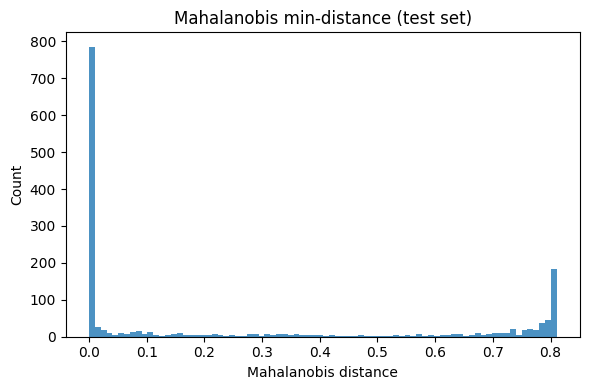

Threshold (95th percentile of val): 0.809482457453214
Abstention threshold = 0.8095 | Coverage = 0.960 | Accuracy on accepted = 0.9724
Saved Mahalanobis outputs to results/figs_breakhis/.


In [15]:
# -----------------------------
# Cell C: Mahalanobis-based uncertainty & abstention (feature-space)
# -----------------------------
import os, numpy as np, matplotlib.pyplot as plt
from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_auc_score, accuracy_score
import scipy
os.makedirs("results/figs_breakhis", exist_ok=True)

# 1) Choose reference data to compute class means & covariance (prefer train_ds or val_ds)
if "train_ds" in globals():
    ref_ds = train_ds
    print("Using train_ds for reference features.")
elif "val_ds" in globals():
    ref_ds = val_ds
    print("train_ds not found; using val_ds for reference features.")
else:
    print("train_ds/val_ds not found — using test_ds for reference (not ideal).")
    ref_ds = test_ds.take( max(1, int(0.2 * (y_true.shape[0] / 32))) )

# 2) Build feature extractor: find last layer before final Dense or global pooling
def find_feature_layer(model):
    # prefer a layer with output_shape length==2 (batch, features)
    for layer in reversed(model.layers):
        shp = getattr(layer, "output_shape", None)
        if shp is None:
            continue
        if isinstance(shp, tuple) and len(shp) == 2:
            return layer.name
    # fallback: find a conv/global pooling
    for layer in reversed(model.layers):
        if "global" in layer.name or "pool" in layer.name:
            return layer.name
    # last layer fallback
    return model.layers[-2].name

feat_layer = find_feature_layer(best_model)
print("Using feature layer:", feat_layer)

from tensorflow.keras.models import Model
feat_extractor = Model(inputs=best_model.inputs, outputs=best_model.get_layer(feat_layer).output)

# 3) Collect features and labels
features = []
labels = []
for imgs, labs in ref_ds:
    feats = feat_extractor.predict(imgs, verbose=0)
    if feats.ndim > 2:
        feats = feats.reshape((feats.shape[0], -1))
    features.append(feats)
    labels.append(labs.numpy())
features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)
print("Collected reference features:", features.shape)

# 4) Compute class means and shared covariance (regularized)
classes = np.unique(labels)
class_means = []
for c in classes:
    class_means.append(features[labels == c].mean(axis=0))
class_means = np.vstack(class_means)  # (n_classes, dim)

# pooled covariance (empirical)
cov = np.cov(features, rowvar=False)
reg = 1e-5 * np.eye(cov.shape[0])
cov_reg = cov + reg
inv_cov = np.linalg.inv(cov_reg)

# 5) Mahalanobis distance function
def mahalanobis_score(x_feat, means=class_means, invcov=inv_cov):
    # x_feat: (d,) or (n, d)
    x = np.atleast_2d(x_feat)
    dists = []
    for mu in means:
        diff = x - mu.reshape(1, -1)
        # vectorized mahalanobis: sqrt(diff @ invcov @ diff.T) per row
        m = np.einsum('ij,jk,ik->i', diff, invcov, diff)
        dists.append(m)
    dists = np.stack(dists, axis=1)  # (n, n_classes)
    # score is minimum distance to any class (lower -> in-distribution)
    return dists.min(axis=1), dists  # (min_dist, all_dists)

# 6) Compute Mahalanobis for test set
# extract features for test set
test_feats = []
for imgs, labs in test_ds:
    f = feat_extractor.predict(imgs, verbose=0)
    if f.ndim > 2:
        f = f.reshape((f.shape[0], -1))
    test_feats.append(f)
test_feats = np.concatenate(test_feats, axis=0)
print("Test features:", test_feats.shape)

min_dists_test, all_dists_test = mahalanobis_score(test_feats)

# 7) Plot histogram of distances (lower = in-distribution)
plt.figure(figsize=(6,4))
plt.hist(min_dists_test, bins=80, alpha=0.8)
plt.title("Mahalanobis min-distance (test set)")
plt.xlabel("Mahalanobis distance")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/figs_breakhis/mahalanobis_hist_test.png", dpi=300)
plt.show()

# 8) If you have an OOD dataset (ood_ds), compute scores and AUROC
if "ood_ds" in globals():
    ood_feats = []
    for imgs, _ in ood_ds:
        f = feat_extractor.predict(imgs, verbose=0)
        if f.ndim > 2:
            f = f.reshape((f.shape[0], -1))
        ood_feats.append(f)
    ood_feats = np.concatenate(ood_feats, axis=0)
    min_dists_ood, _ = mahalanobis_score(ood_feats)
    y_true_ood = np.concatenate([np.zeros(len(min_dists_test)), np.ones(len(min_dists_ood))])  # 0=in, 1=ood
    scores = np.concatenate([min_dists_test, min_dists_ood])
    auroc = roc_auc_score(y_true_ood, scores)
    print("OOD detection AUROC (Mahalanobis):", auroc)
    # plot ROC
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_true_ood, scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0,1],[0,1],'k--')
    plt.title("OOD detection ROC (Mahalanobis)")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig("results/figs_breakhis/mahalanobis_ood_roc.png", dpi=300)
    plt.show()

# 9) Abstention policy: choose threshold on validation distances (e.g., 95th percentile)
# If val_ds exists, use its distances; else use test distances but warn
if "val_ds" in globals():
    # compute val distances
    val_feats = []
    for imgs, labs in val_ds:
        f = feat_extractor.predict(imgs, verbose=0)
        if f.ndim > 2: f = f.reshape((f.shape[0], -1))
        val_feats.append(f)
    val_feats = np.concatenate(val_feats, axis=0)
    val_min, _ = mahalanobis_score(val_feats)
    thr = np.percentile(val_min, 95)
    print("Threshold (95th percentile of val):", thr)
else:
    print("val_ds not found — using 95th percentile of test distances for threshold (not ideal).")
    thr = np.percentile(min_dists_test, 95)
    print("Threshold (95th pct of test):", thr)

# Evaluate abstention (reject if distance > thr)
accept_mask = min_dists_test <= thr
coverage = accept_mask.mean()
acc_accept = accuracy_score(y_true[accept_mask], y_pred[accept_mask]) if accept_mask.sum() > 0 else float("nan")
print(f"Abstention threshold = {thr:.4f} | Coverage = {coverage:.3f} | Accuracy on accepted = {acc_accept:.4f}")

# Save distances & threshold
np.savez("results/figs_breakhis/mahalanobis_results.npz",
         min_dists_test=min_dists_test, threshold=thr, accept_mask=accept_mask)
print("Saved Mahalanobis outputs to results/figs_breakhis/.")


In [16]:
# ===========================
# Cell 1 — Feature extraction (for evidential head training)
# ===========================
import os, numpy as np, tensorflow as tf, gc
from tensorflow.keras.models import Model
os.makedirs("results/figs_breakhis", exist_ok=True)

# Safety checks
if "best_model" not in globals():
    raise RuntimeError("best_model not found. Run the model-loading/eval cell first.")

# 1) Pick a reasonable feature layer (penultimate dense or global pool)
def find_feature_layer(model):
    # Prefer a layer producing (batch, features)
    for layer in reversed(model.layers):
        out_shape = getattr(layer, "output_shape", None)
        if out_shape is None:
            continue
        if isinstance(out_shape, tuple) and len(out_shape) == 2:
            return layer.name
    # fallback to global pooling or second-last
    for layer in reversed(model.layers):
        if "global" in layer.name or "pool" in layer.name:
            return layer.name
    return model.layers[-2].name

feat_layer_name = find_feature_layer(best_model)
print("Selected feature layer:", feat_layer_name)

feat_extractor = Model(inputs=best_model.inputs, outputs=best_model.get_layer(feat_layer_name).output)
print("Feature extractor ready.")

def extract_features(ds, name):
    feats = []; labels = []
    for imgs, labs in ds:
        f = feat_extractor.predict(imgs, verbose=0)
        # flatten spatial dimensions if present
        if f.ndim > 2:
            f = f.reshape((f.shape[0], -1))
        feats.append(f)
        labels.append(labs.numpy())
    if len(feats) == 0:
        return None, None
    feats = np.concatenate(feats, axis=0)
    labels = np.concatenate(labels, axis=0)
    print(f"{name} --> features: {feats.shape}, labels: {labels.shape}")
    return feats, labels

# Try to extract from train/val/test if available. Use small fallbacks if not.
feat_train, y_train_feat = (None, None)
feat_val, y_val_feat = (None, None)
feat_test, y_test_feat = (None, None)

if "train_ds" in globals():
    feat_train, y_train_feat = extract_features(train_ds, "train")
else:
    print("train_ds not found. Skipping train feature extraction (you may provide train_ds later).")

if "val_ds" in globals():
    feat_val, y_val_feat = extract_features(val_ds, "val")
else:
    print("val_ds not found. If you have a labeled val set, assign it to 'val_ds' for best results.")

# always extract test features (test_ds exists in your pipeline)
feat_test, y_test_feat = extract_features(test_ds, "test")
# Save features for later reuse (avoid repeated extraction)
np.savez("results/figs_breakhis/features_saved.npz",
         feat_train=feat_train, y_train_feat=y_train_feat,
         feat_val=feat_val, y_val_feat=y_val_feat,
         feat_test=feat_test, y_test_feat=y_test_feat)
print("Saved features to results/figs_breakhis/features_saved.npz")

gc.collect()


Selected feature layer: dense
Feature extractor ready.
train --> features: (5536, 2), labels: (5536,)
val --> features: (791, 2), labels: (791,)
test --> features: (1582, 2), labels: (1582,)
Saved features to results/figs_breakhis/features_saved.npz


39004

In [18]:
# ===========================
# Cell 2 — Train evidential head on features (fixed dtype version)
# ===========================
import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
os.makedirs("results/figs_breakhis", exist_ok=True)

# load saved features
data = np.load("results/figs_breakhis/features_saved.npz", allow_pickle=True)
feat_train = data.get("feat_train", None)
y_train_feat = data.get("y_train_feat", None)
feat_val = data.get("feat_val", None)
y_val_feat = data.get("y_val_feat", None)
feat_test = data.get("feat_test", None)
y_test_feat = data.get("y_test_feat", None)

# fallback if no train/val
if feat_train is None and feat_val is None:
    print("⚠️ No train/val features found — using small subset of test features for evidential head training.")
    n = feat_test.shape[0]
    idx = np.random.choice(n, size=max(100, int(0.1 * n)), replace=False)
    feat_train = feat_test[idx]
    y_train_feat = y_test_feat[idx]

n_classes = int(np.max(y_test_feat) + 1) if y_test_feat is not None else int(np.max(y_train_feat) + 1)
print("Detected classes:", n_classes)

# Ensure float32 everywhere
feat_train = feat_train.astype("float32")
if feat_val is not None: feat_val = feat_val.astype("float32")
y_train_feat = y_train_feat.astype("int32")
if y_val_feat is not None: y_val_feat = y_val_feat.astype("int32")

y_train_oh = tf.cast(to_categorical(y_train_feat, num_classes=n_classes), tf.float32)
if feat_val is not None:
    y_val_oh = tf.cast(to_categorical(y_val_feat, num_classes=n_classes), tf.float32)
else:
    feat_val, y_val_oh = None, None

# ---- Model ----
input_dim = feat_train.shape[1]
hidden = 128 if input_dim < 4096 else 256
inp = layers.Input(shape=(input_dim,), name="feat_input")
x = layers.Dense(hidden, activation="relu")(inp)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(hidden // 2, activation="relu")(x)
out = layers.Dense(n_classes, activation=None)(x)
model_evid = models.Model(inp, out, name="evidential_head")
model_evid.summary()

# ---- Evidential loss ----
def edl_loss(y_true, logits, epoch=None, annealing_step=10):
    y_true = tf.cast(y_true, tf.float32)
    logits = tf.cast(logits, tf.float32)
    n_classes_tf = tf.cast(tf.shape(y_true)[1], tf.float32)

    evidence = tf.nn.softplus(logits)  # >= 0
    alpha = evidence + 1.0
    S = tf.reduce_sum(alpha, axis=1, keepdims=True)
    logp = tf.math.digamma(alpha) - tf.math.digamma(S)
    nll = -tf.reduce_sum(y_true * logp, axis=1)

    # KL divergence Dir(alpha)||Dir(1)
    lgamma = tf.math.lgamma
    digamma = tf.math.digamma
    S_scalar = tf.reduce_sum(alpha, axis=1)
    term1 = lgamma(S_scalar)
    term2 = tf.reduce_sum(lgamma(alpha), axis=1)
    term3 = lgamma(n_classes_tf)
    term4 = tf.reduce_sum((alpha - 1.0) * (digamma(alpha) - tf.reshape(digamma(S_scalar), (-1,1))), axis=1)
    kl = term1 - term2 - term3 + term4

    anneal = 1.0 if epoch is None else float(min(1.0, epoch / annealing_step))
    loss = nll + 0.01 * anneal * kl
    return tf.reduce_mean(loss)

# ---- Training loop ----
optimizer = tf.keras.optimizers.Adam(1e-3)
train_ds = tf.data.Dataset.from_tensor_slices((feat_train, y_train_oh)).shuffle(1024).batch(64)
val_ds = None
if feat_val is not None:
    val_ds = tf.data.Dataset.from_tensor_slices((feat_val, y_val_oh)).batch(128)

best_val = 1e9
patience = 6
pat_cnt = 0
EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
    train_loss = tf.metrics.Mean()
    for x_batch, y_batch in train_ds:
        with tf.GradientTape() as tape:
            logits = model_evid(x_batch, training=True)
            loss_value = edl_loss(y_batch, logits, epoch=epoch, annealing_step=8)
        grads = tape.gradient(loss_value, model_evid.trainable_weights)
        optimizer.apply_gradients(zip(grads, model_evid.trainable_weights))
        train_loss.update_state(loss_value)

    val_loss_value = train_loss.result().numpy()
    if val_ds is not None:
        val_metric = tf.metrics.Mean()
        for x_batch, y_batch in val_ds:
            logits = model_evid(x_batch, training=False)
            vl = edl_loss(y_batch, logits, epoch=epoch)
            val_metric.update_state(vl)
        val_loss_value = val_metric.result().numpy()

    print(f"Epoch {epoch:02d} | train_loss={train_loss.result().numpy():.4f} | val_loss={val_loss_value:.4f}")
    if val_loss_value < best_val - 1e-4:
        best_val = val_loss_value
        model_evid.save("results/figs_breakhis/evidential_head_best.h5", include_optimizer=False)
        pat_cnt = 0
    else:
        pat_cnt += 1
    if pat_cnt >= patience:
        print("Early stopping.")
        break

if os.path.exists("results/figs_breakhis/evidential_head_best.h5"):
    model_evid = tf.keras.models.load_model("results/figs_breakhis/evidential_head_best.h5", compile=False)
    print("Loaded best evidential head.")

# ---- Test evidential outputs ----
if feat_test is not None:
    logits_test = model_evid.predict(feat_test.astype("float32"), verbose=0)
    evidence_test = tf.nn.softplus(logits_test).numpy()
    alpha_test = evidence_test + 1.0
    S = alpha_test.sum(axis=1, keepdims=True)
    p_evid = alpha_test / S
    vacuity = (alpha_test.shape[1] / S).flatten()
    np.savez("results/figs_breakhis/evidential_outputs_test.npz",
             logits_test=logits_test, evidence_test=evidence_test,
             alpha_test=alpha_test, p_evid=p_evid, vacuity=vacuity)
    print("Saved evidential outputs for test set.")


Detected classes: 2
Model: "evidential_head"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 feat_input (InputLayer)     [(None, 2)]               0         
                                                                 
 dense_4 (Dense)             (None, 128)               384       
                                                                 
 batch_normalization_2 (Batc  (None, 128)              512       
 hNormalization)                                                 
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 64)                8256      
                                                                 
 dense_6 (Dense)             (None, 2)                 130       
                               

In [19]:
# ===========================
# Cell 3 — Evidential Δ-Addition (selective refinement + abstention)
# ===========================
import os, numpy as np, tensorflow as tf, pandas as pd, gc
from sklearn.metrics import accuracy_score, classification_report
os.makedirs("results/figs_breakhis", exist_ok=True)

# load evidential head outputs if saved; otherwise compute on the fly
if os.path.exists("results/figs_breakhis/evidential_outputs_test.npz"):
    data = np.load("results/figs_breakhis/evidential_outputs_test.npz", allow_pickle=True)
    p_evid = data["p_evid"]
    vac_test = data["vacuity"]
    alpha_test = data["alpha_test"]
else:
    # compute from feature extractor & evidential head
    # feat_test must exist from Cell1
    if 'feat_test' not in globals() or feat_test is None:
        data = np.load("results/figs_breakhis/features_saved.npz", allow_pickle=True)
        feat_test = data["feat_test"]
        y_test_feat = data["y_test_feat"]
    logits_test = model_evid.predict(feat_test, verbose=0)
    evidence_test = tf.nn.softplus(logits_test).numpy()
    alpha_test = evidence_test + 1.0
    S = alpha_test.sum(axis=1, keepdims=True)
    p_evid = alpha_test / S
    vac_test = (alpha_test.shape[1] / S).flatten()

# base predictions & base probs (y_pred, y_prob) must exist from your base evaluation cell
if "y_pred" not in globals() or "y_prob" not in globals():
    raise RuntimeError("y_pred / y_prob not available. Run base evaluation cell first.")

# Config (conservative defaults)
VACUITY_THRESHOLD = 0.08   # if vacuity > this -> sample is uncertain (tune)
MC_SAMPLES = 8
NOISE_STD = 0.005
USE_DROPOUT = True
MIN_MC_IMPROVEMENT = 0.02  # MC mean top prob must exceed base top by at least this
MAJORITY_FRAC = 0.6        # require MC majority for acceptance

# helper to enable dropout
def enable_dropout(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Dropout):
            layer.training = True

# We'll iterate dataset to locate images whose vacuity > threshold, then refine them
y_pred_refined = y_pred.copy()
changed = []
idx_ptr = 0
total_checked = 0
total_refined = 0

for imgs, labs in test_ds:
    imgs = tf.cast(imgs, tf.float32)
    b = imgs.shape[0]
    base_probs_batch = y_prob[idx_ptr:idx_ptr+b]
    for j in range(b):
        global_idx = idx_ptr + j
        vac = float(vac_test[global_idx]) if len(vac_test)==len(y_pred) else float(vac_test[global_idx])
        if vac <= VACUITY_THRESHOLD:
            continue  # confident enough, skip expensive refinement
        total_checked += 1

        img = imgs[j:j+1]
        base_top = float(np.max(base_probs_batch[j])); base_pred = int(np.argmax(base_probs_batch[j]))

        # run MC per-sample
        votes = []
        sum_p = None
        for s in range(MC_SAMPLES):
            noisy = img + tf.random.normal(tf.shape(img), stddev=NOISE_STD)
            if USE_DROPOUT:
                enable_dropout(best_model)
            p = best_model(noisy, training=True).numpy().reshape(-1)
            votes.append(int(np.argmax(p)))
            if sum_p is None:
                sum_p = p.astype(np.float64)
            else:
                sum_p += p
        mean_p = sum_p / MC_SAMPLES
        mc_top = float(np.max(mean_p)); mc_pred = int(np.argmax(mean_p))
        votes = np.array(votes)
        maj_frac = np.bincount(votes, minlength=mean_p.size)[mc_pred] / MC_SAMPLES

        # acceptance: majority + improvement + stability approximation (use maj_frac as proxy)
        if maj_frac >= MAJORITY_FRAC and (mc_top >= base_top + MIN_MC_IMPROVEMENT):
            if mc_pred != base_pred:
                y_pred_refined[global_idx] = mc_pred
                changed.append({
                    "index": int(global_idx),
                    "true": int(y_true[global_idx]),
                    "base_pred": int(base_pred),
                    "mc_pred": int(mc_pred),
                    "vacuity": vac,
                    "base_top": base_top,
                    "mc_top": mc_top,
                    "maj_frac": float(maj_frac)
                })
                total_refined += 1
    idx_ptr += b
    gc.collect()

acc_before = accuracy_score(y_true, y_pred)
acc_after = accuracy_score(y_true, y_pred_refined)
print("Evidential Δ-Addition (selective): checked", total_checked, "accepted/refined", total_refined)
print("Accuracy before:", acc_before, "after:", acc_after, "delta:", acc_after - acc_before)

# Save changed list
if len(changed) > 0:
    pd.DataFrame(changed).to_csv("results/figs_breakhis/evidential_delta_changed.csv", index=False)
    print("Saved changed samples list to results/figs_breakhis/evidential_delta_changed.csv")

# Print classification report on accepted subset (optional)
print("Classification report (after evidential Δ):")
print(classification_report(y_true, y_pred_refined, target_names=class_names, digits=4))


Evidential Δ-Addition (selective): checked 131 accepted/refined 5
Accuracy before: 0.972819216182048 after: 0.9721871049304678 delta: -0.0006321112515802474
Saved changed samples list to results/figs_breakhis/evidential_delta_changed.csv
Classification report (after evidential Δ):
              precision    recall  f1-score   support

      benign     0.9431    0.9698    0.9563       496
   malignant     0.9860    0.9733    0.9796      1086

    accuracy                         0.9722      1582
   macro avg     0.9646    0.9715    0.9679      1582
weighted avg     0.9726    0.9722    0.9723      1582

